In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('C:\\Users\\DELL\\Documents\\Python\\CSV\\Admission_Predict_Ver1.1.csv')

In [3]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.shape

(500, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [8]:
df.dtypes

Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop(['Serial No.'], axis = 1, inplace = True)

In [18]:
x = df.iloc[: , :-1]
y = df.iloc[: ,-1]

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split( x, y, train_size=0.8)

In [23]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()

x_train_s = mm.fit_transform(x_train)
x_test_s = mm.transform(x_test)

In [27]:
from tensorflow import keras

from tensorflow.keras import Sequential

from keras.layers import Dense

In [54]:
model = Sequential()

model.add(Dense(20, activation = 'relu', input_dim = 7))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(1, activation = 'linear'))

# Linear is used in regression problems

In [55]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 20)                160       
                                                                 
 dense_10 (Dense)            (None, 10)                210       
                                                                 
 dense_11 (Dense)            (None, 1)                 11        
                                                                 
Total params: 381 (1.49 KB)
Trainable params: 381 (1.49 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [56]:
model.compile( loss = 'mean_squared_error', optimizer = 'Adam')

In [57]:
his = model.fit(x_train_s, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
10/10 [==============================] - 1s 27ms/step - loss: 0.2846 - val_loss: 0.1661
Epoch 2/50
10/10 [==============================] - 0s 7ms/step - loss: 0.0898 - val_loss: 0.0406
Epoch 3/50
10/10 [==============================] - 0s 8ms/step - loss: 0.0290 - val_loss: 0.0279
Epoch 4/50
10/10 [==============================] - 0s 8ms/step - loss: 0.0290 - val_loss: 0.0233
Epoch 5/50
10/10 [==============================] - 0s 9ms/step - loss: 0.0202 - val_loss: 0.0170
Epoch 6/50
10/10 [==============================] - 0s 8ms/step - loss: 0.0154 - val_loss: 0.0155
Epoch 7/50
10/10 [==============================] - 0s 9ms/step - loss: 0.0130 - val_loss: 0.0124
Epoch 8/50
10/10 [==============================] - 0s 8ms/step - loss: 0.0110 - val_loss: 0.0104
Epoch 9/50
10/10 [==============================] - 0s 8ms/step - loss: 0.0099 - val_loss: 0.0094
Epoch 10/50
10/10 [==============================] - 0s 10ms/step - loss: 0.0089 - val_loss: 0.0087
Epoch 11/50
10/10

In [58]:
y_pred = model.predict(x_test_s)

4/4 [==============================] - 0s 5ms/step


In [59]:
from sklearn.metrics import r2_score

In [60]:
r2_score(y_pred, y_test)

0.8741751915343275

In [61]:
import matplotlib.pyplot as plt

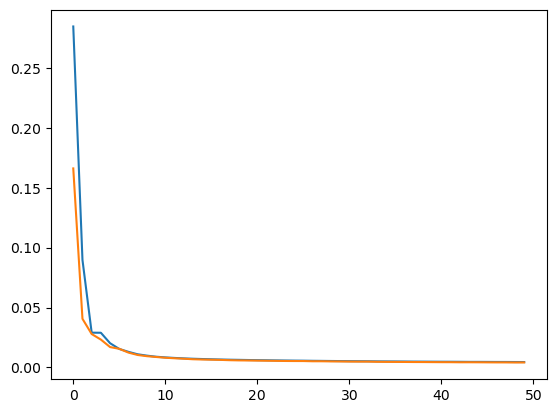

In [63]:
plt.plot(his.history['loss'])
plt.plot(his.history['val_loss'])